In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import src.load_csv as lc
import src.make_dateset as md

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn

import pymc as pm
import arviz as az
import pytensor

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("matplotlib:",matplotlib.__version__)
print("scipy:",scipy.__version__)
print("sklearn:",sklearn.__version__)

print("pymc:", pm.__version__)
print("arviz:", az.__version__)
print("pytensor:", pytensor.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8
scipy: 1.17.1
sklearn: 1.8.0
pymc: 5.28.2
arviz: 0.23.4
pytensor: 2.38.2


In [2]:
# PyMCはコンパイルしたものをCで実行しているらしいので実行環境が別途必要
import shutil
print(shutil.which("g++"))

C:\msys64\ucrt64\bin\g++.EXE


# Modelの練習
## ベータ分布・ベルヌーイ分布
$$
X|p \sim \text{Be}(p)\ , \ p \sim \text{Beta}(\alpha , \beta)
$$
$p$の事後分布
$$
p|\vec{X}=\vec{x} \sim \text{Beta}(\hat{\alpha} , \hat{\beta}) = \text{Beta}\left(\sum_i x_i  + \alpha , N-\sum_i x_i + \beta\right)
$$
これは計算できるから
$$
\hat{\alpha} = \sum_i x_i  + \alpha \ , \ \hat{\beta} = N-\sum_i x_i + \beta
$$
だけど、MCMCで実施してみる

In [3]:
# 観測データ: 1=表, 0=裏
x_data = np.array([1, 0, 1, 1, 0 ])
sum_x = x_data.sum()
n = len(x_data)
print(sum_x)
print(n)

3
5


In [4]:
alpha=2
beta=2
hat_alpha = sum_x + alpha
hat_beta = n - sum_x + beta
print(hat_alpha)
print(hat_beta)

5
4


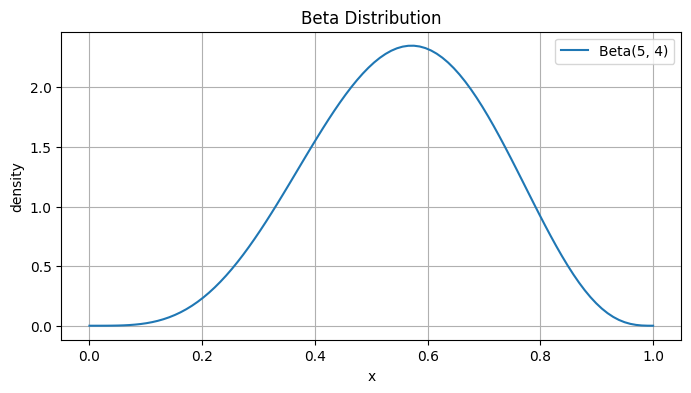

In [5]:
from scipy.stats import beta
# x軸（0〜1）
x = np.linspace(0, 1, 100)

# 確率密度関数
y = beta.pdf(x, hat_alpha, hat_beta)

# プロット
plt.figure(figsize=(8, 4))
plt.plot(x, y, label=f"Beta({hat_alpha}, {hat_beta})")
plt.title("Beta Distribution")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
with pm.Model() as beta_bernoulli_model:
    # 事前分布
    p = pm.Beta("p", alpha=2, beta=2)

    # 尤度
    # observed (観測された)
    x_obs = pm.Bernoulli("x_obs", p=p, observed=x_data)

    # MCMC
    trace = pm.sample(
        draws=2000, # 本番サンプル数
        tune=1000, # 捨てるサンプル数
        chains=4, # 独立なMCMCの数
        target_accept=0.9, # 採択する基準 
        return_inferencedata=True # Arvizで返してライブラリを使えるようにする
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 29 seconds.


In [7]:
az.summary(trace, var_names=["p"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.558,0.157,0.28,0.851,0.003,0.002,2925.0,3474.0,1.0


array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

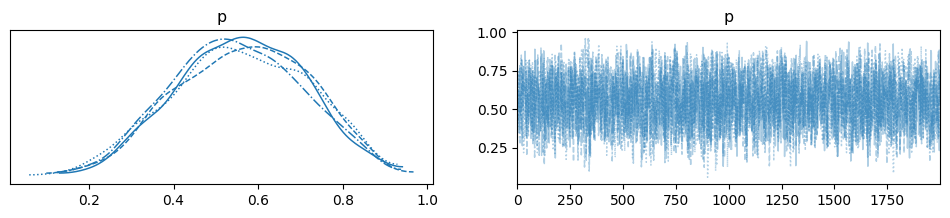

In [8]:
az.plot_trace(trace)

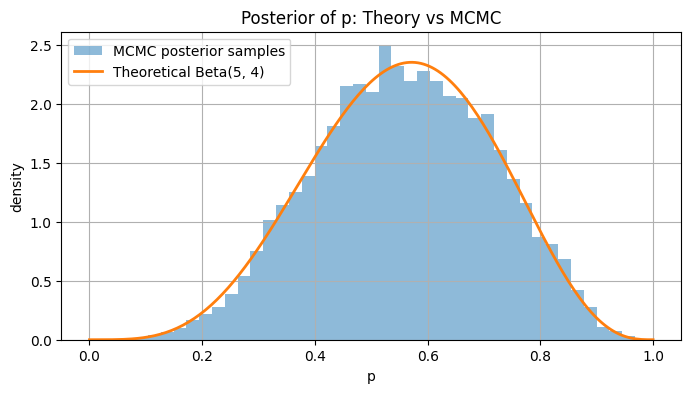

In [9]:
# MCMCサンプルを取り出す
p_samples = trace.posterior["p"].values.flatten()

# 理論曲線
x = np.linspace(0, 1, 200)
y = beta.pdf(x, hat_alpha, hat_beta)

# 重ね描き
plt.figure(figsize=(8, 4))
plt.hist(p_samples, bins=40, density=True, alpha=0.5, label="MCMC posterior samples")
plt.plot(x, y, linewidth=2, label=f"Theoretical Beta({hat_alpha}, {hat_beta})")

plt.title("Posterior of p: Theory vs MCMC")
plt.xlabel("p")
plt.ylabel("density")
plt.grid(True)
plt.legend()
plt.show()

## MCMC Summary の見方

| 指標 | 意味 | 解釈のポイント |
|------|------|----------------|
| mean | 事後平均（点推定） | 収束していれば代表値として使用 |
| sd | 事後標準偏差 | 不確実性の大きさ |
| hdi_3%, hdi_97% | 信用区間（HDI） | パラメータが高確率で存在する範囲 |
| mcse_mean | 平均のモンテカルロ誤差 | 小さいほど推定が安定 |
| mcse_sd | 分散のモンテカルロ誤差 | 小さいほど推定が安定 |
| ess_bulk | 有効サンプルサイズ（中心） | 100以上が最低ライン |
| ess_tail | 有効サンプルサイズ（裾） | 分布の端の精度指標 |
| r_hat | 収束判定指標 | 1.01未満が理想 |

## 判定基準

| 指標 | 基準 | 解釈 |
|------|------|------|
| r_hat | < 1.01 | 収束している |
| r_hat | 1.01〜1.05 | やや不安 |
| r_hat | > 1.1 | 未収束（解釈不可） |
| ess_bulk | > 100 | 最低限OK |
| ess_bulk | > 1000 | 理想的 |
| ess_tail | > 100 | 裾の推定も安定 |

## 解釈の原則

- r_hat と ESS を最優先で確認する
- 収束していない場合、mean や HDI は解釈しない
- 潜在変数モデルでは ESS が低くなりやすい

## 一言まとめ

MCMCの結果は「値」ではなく「収束しているか」で判断する

# ガンマ分布・ポアソン分布
$$
X|\lambda \sim \text{Poisson} (\lambda)\ , \ \lambda \sim \text{Ga}(\alpha,\beta)
$$
$\lambda$の事後分布
$$
\lambda|\vec{X}=\vec{x} \sim \text{Ga}\left(\sum_i x_i + \alpha , n + \beta\right)
$$

In [12]:
# 観測データ（カウント）
x_data = np.array([3, 2, 4, 3, 5])  # 合計17, n=5

# 事前分布パラメータ
alpha_prior = 2.0
beta_prior = 1.0

# 事後分布パラメータ
hat_alpha = x_data.sum() + alpha_prior
hat_beta = len(x_data) + beta_prior

print(hat_alpha)
print(hat_beta)

19.0
6.0


In [13]:
with pm.Model() as gamma_poisson_model:
    # 事前分布
    lam = pm.Gamma("lam", alpha=alpha_prior, beta=beta_prior)

    # 尤度
    x_obs = pm.Poisson("x_obs", mu=lam, observed=x_data)

    # MCMC
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 27 seconds.


In [14]:
az.summary(trace, var_names=["lam"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lam,3.17,0.727,1.847,4.524,0.014,0.008,2680.0,3215.0,1.0


array([[<Axes: title={'center': 'lam'}>, <Axes: title={'center': 'lam'}>]],
      dtype=object)

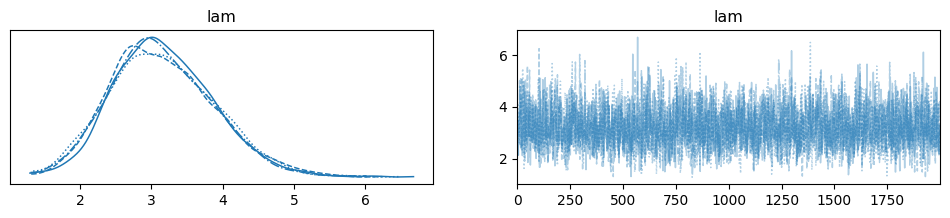

In [15]:
az.plot_trace(trace)

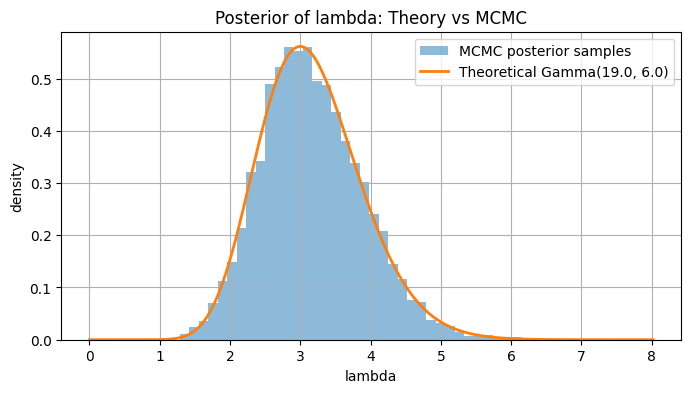

In [16]:
from scipy.stats import gamma

# MCMCサンプルを取り出す
lam_samples = trace.posterior["lam"].values.flatten()

# 理論事後分布の x 軸
x = np.linspace(0, lam_samples.max() * 1.2, 300)

# scipy の gamma は scale=1/beta
y = gamma.pdf(x, a=hat_alpha, scale=1/hat_beta)

# 重ね描き
plt.figure(figsize=(8, 4))
plt.hist(lam_samples, bins=40, density=True, alpha=0.5, label="MCMC posterior samples")
plt.plot(x, y, linewidth=2, label=f"Theoretical Gamma({hat_alpha}, {hat_beta})")

plt.title("Posterior of lambda: Theory vs MCMC")
plt.xlabel("lambda")
plt.ylabel("density")
plt.grid(True)
plt.legend()
plt.show()